
# Time Series Forecasting with Bike Sharing (2025 Edition)

This refreshed notebook walks through modern exploratory analysis, classical forecasting, and machine learning / deep learning pipelines for hourly bike rentals. The focus is on building robust multi-horizon forecasts (1, 2, and 3 hours ahead) while keeping a strong emphasis on explainability and reproducibility.



## Roadmap

1. Load and sanity-check the hourly bike sharing data (UTC indexed).
2. Perform rich exploratory data analysis (EDA) including temporal aggregations, heat maps, and anomaly checks.
3. Review the concept of stationarity with equations, tests, and decompositions (STL, ACF/PACF).
4. Discuss time-series specific data splitting and feature engineering for machine learning and deep learning.
5. Engineer lag-based and seasonal features, exponential moving averages (EMA), and seasonal carry-overs.
6. Train tuned XGBoost and CatBoost models for 1, 2, and 3 hour horizons.
7. Train a feed-forward neural network and an LSTM using PyTorch, then build a simple ensemble.
8. Compare with an AutoML baseline and summarise metrics (R², RMSE, MAE) across horizons.



## Environment Check & Dependencies

The following cell detects whether the notebook runs in Google Colab or a local environment and makes sure required packages are available. Installing heavy dependencies (e.g. PyTorch) can take a minute.


In [1]:

from __future__ import annotations
import importlib
import importlib.util
import subprocess
import sys
from typing import Optional

try:
    import google.colab  # type: ignore
    RUNNING_IN_COLAB = True
    print('Running inside Google Colab.')
except ImportError:
    RUNNING_IN_COLAB = False
    print('Running in a local Jupyter environment.')

REQUIRED_PACKAGES = [
    ('pandas', 'pandas', None),
    ('numpy', 'numpy', None),
    ('matplotlib', 'matplotlib', None),
    ('seaborn', 'seaborn', None),
    ('statsmodels', 'statsmodels', None),
    ('sklearn', 'scikit-learn', None),
    ('xgboost', 'xgboost', None),
    ('catboost', 'catboost', None),
    ('optuna', 'optuna', None),
    ('flaml', 'flaml', None),
    ('torch', 'torch', 'https://download.pytorch.org/whl/cpu'),
]


def ensure_package(module_name: str, pip_name: Optional[str] = None, index_url: Optional[str] = None) -> None:
    """Install ``pip_name`` if ``module_name`` cannot be imported."""
    if importlib.util.find_spec(module_name) is not None:
        return
    cmd = [sys.executable, '-m', 'pip', 'install']
    if index_url:
        cmd += ['--index-url', index_url]
    cmd.append(pip_name or module_name)
    print(f'Installing {pip_name or module_name} ...')
    subprocess.check_call(cmd)


for module_name, pip_name, index_url in REQUIRED_PACKAGES:
    try:
        ensure_package(module_name, pip_name, index_url)
    except Exception as exc:  # pragma: no cover
        print(f'Warning: failed to install {pip_name}: {exc}')
        raise


Running in a local Jupyter environment.


In [2]:

import sys
from pathlib import Path
import subprocess

possible_dirs = [
    Path.cwd() / 'scripts',
    Path.cwd() / 'lectures' / 'L04_Timeseries' / 'scripts',
]
LOCAL_SCRIPT_DIR = None
for candidate in possible_dirs:
    if candidate.exists():
        LOCAL_SCRIPT_DIR = candidate
        break

if RUNNING_IN_COLAB and LOCAL_SCRIPT_DIR is None:
    LOCAL_SCRIPT_DIR = Path('/content/scripts')
    LOCAL_SCRIPT_DIR.mkdir(parents=True, exist_ok=True)
    base_url = 'https://raw.githubusercontent.com/francji1/01ADS/refs/heads/main/lectures/L04_Timeseries/scripts'
    helper_files = ['timeseries_utils.py', 'run_xgboost.py', 'run_catboost.py', 'run_mlp.py', 'run_lstm.py']
    for fname in helper_files:
        url = f"{base_url}/{fname}"
        try:
            subprocess.check_call(['wget', '-q', '-O', str(LOCAL_SCRIPT_DIR / fname), url])
        except Exception as exc:
            print(f'Warning: failed to download {fname}: {exc}')

if LOCAL_SCRIPT_DIR and LOCAL_SCRIPT_DIR.exists():
    script_path = LOCAL_SCRIPT_DIR.resolve()
    if str(script_path) not in sys.path:
        sys.path.append(str(script_path))
    print(f'Helper scripts directory: {script_path}')
else:
    print('Warning: helper scripts directory not found. Some functionality may be unavailable.')


Helper scripts directory: \\data.fjfi.cvut.cz\home\francji1\01ADS\01ADS\lectures\L04_Timeseries\scripts


In [3]:
import math
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import optuna
from flaml import AutoML

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from timeseries_utils import (
    load_bike_data,
    SplitData,
    create_time_features,
    split_time_series,
    evaluate_metrics,
    prepare_catboost_frame,
    get_categorical_columns,
    create_sequence_data,
)
from run_xgboost import tune_xgb, train_xgb
HAS_CATBOOST = False
try:
    from run_catboost import tune_catboost, train_catboost
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print('CatBoost helpers unavailable; skipping CatBoost model.')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

HORIZONS = [1, 2, 3, 4]


In [4]:
# Imports consolidated in the previous cell

In [5]:

import math
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import optuna
from flaml import AutoML

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [6]:

DATA_URL = 'https://raw.githubusercontent.com/francji1/01DAS/refs/heads/main/data/bike_share_hour3.csv'
RAW_COLUMNS_TO_DROP = ['casual', 'registered', 'instant', 'date']


def load_bike_data(url: str) -> pd.DataFrame:
    """Load bike sharing data, build a UTC datetime index, and drop unused columns."""
    df = pd.read_csv(url)
    if 'datetime' in df.columns:
        dt_series = pd.to_datetime(df['datetime'], utc=True)
    elif {'date', 'hour'}.issubset(df.columns):
        dt_series = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'], unit='h')
        dt_series = dt_series.dt.tz_localize('UTC')
    else:
        raise KeyError('Expected columns "datetime" or "date" + "hour" in the dataset.')

    df['datetime'] = dt_series
    df = df.set_index('datetime').sort_index()

    rename_map = {'weathersit': 'weather', 'weekday': 'dayofweek'}
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    cols_to_drop = [col for col in RAW_COLUMNS_TO_DROP if col in df.columns]
    df = df.drop(columns=cols_to_drop)
    return df


data = load_bike_data(DATA_URL)
print(f'Dataset contains {len(data):,} hourly observations from {data.index.min()} to {data.index.max()}')
data.head()


Dataset contains 17,379 hourly observations from 2011-01-01 00:00:00+00:00 to 2012-12-31 23:00:00+00:00


,season,year,month,hour,holiday,dayofweek,workingday,weather,temp,atemp,hum,windspeed,y
datetime,,,,,,,,,,,,,
2011-01-01 00:00:00+00:00,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
2011-01-01 01:00:00+00:00,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2011-01-01 02:00:00+00:00,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
2011-01-01 03:00:00+00:00,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
2011-01-01 04:00:00+00:00,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1



### Basic Sanity Checks


In [7]:

def summarise_dataframe(df: pd.DataFrame) -> None:
    """Print basic dataset facts."""
    print('Data types:')
    print(df.dtypes)
    print('Missing values per column:')
    print(df.isna().sum())
    print('Five-number summary of the target (y):')
    print(df['y'].describe())

summarise_dataframe(data)


Data types:
season          int64
year            int64
month           int64
hour            int64
holiday         int64
dayofweek       int64
workingday      int64
weather         int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
y               int64
dtype: object
Missing values per column:
season        0
year          0
month         0
hour          0
holiday       0
dayofweek     0
workingday    0
weather       0
temp          0
atemp         0
hum           0
windspeed     0
y             0
dtype: int64
Five-number summary of the target (y):
count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: y, dtype: float64



### Visual Overview of the Target Series

A quick glance at the full series helps spot structural changes, anomalies, or obvious seasonality.


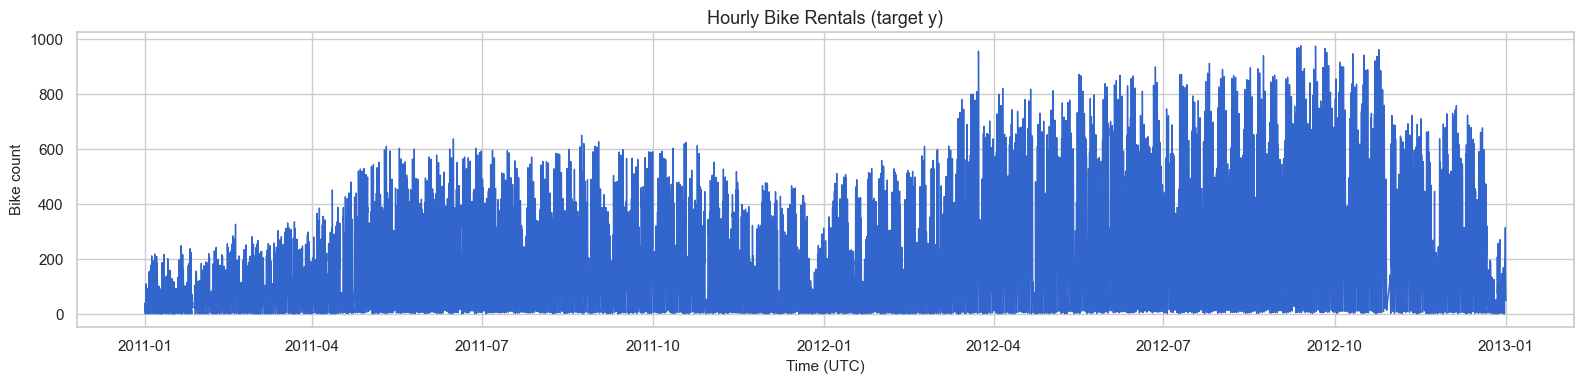

In [8]:

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(data.index, data['y'], color='#3366CC', linewidth=1)
ax.set_title('Hourly Bike Rentals (target y)')
ax.set_ylabel('Bike count')
ax.set_xlabel('Time (UTC)')
plt.tight_layout()
plt.show()



#### Hourly Profile by Day of Week

Box plots highlight how distributions shift across hours and weekdays. Spikes can indicate commuting patterns.


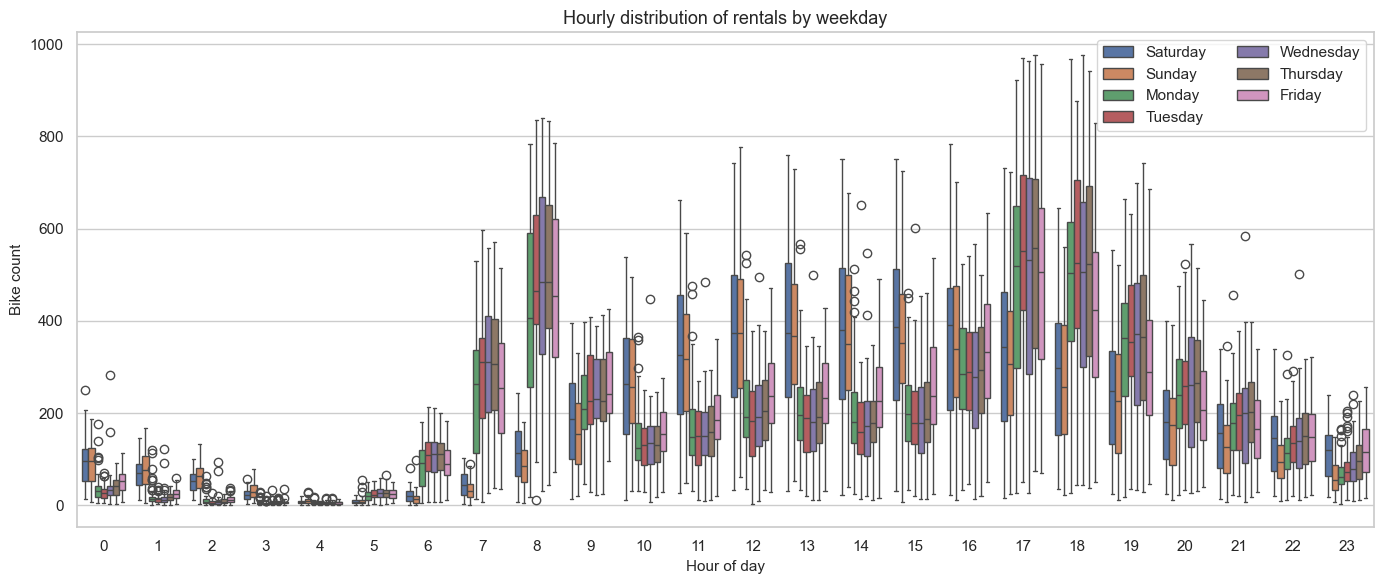

In [9]:

fig, ax = plt.subplots(figsize=(14, 6))
plot_df = data.copy()
plot_df['hour'] = plot_df.index.hour
plot_df['dayofweek'] = plot_df.index.day_name()
sns.boxplot(data=plot_df, x='hour', y='y', hue='dayofweek', ax=ax)
ax.set_title('Hourly distribution of rentals by weekday')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Bike count')
ax.legend(loc='upper right', ncol=2, frameon=True)
plt.tight_layout()
plt.show()



#### Heat Map of Hour vs. Day of Week

A two-dimensional heat map reveals joint seasonality. Peaks around weekday commutes and weekend leisure slots pop out immediately.


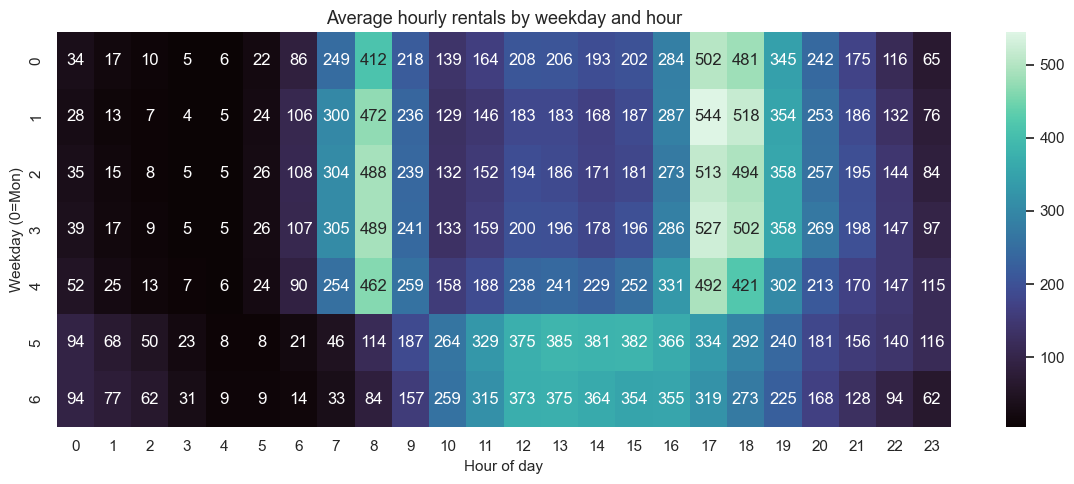

In [10]:

pivot = plot_df.pivot_table(values='y', index=plot_df.index.dayofweek, columns='hour', aggfunc='mean')
plt.figure(figsize=(12, 5))
sns.heatmap(pivot.sort_index(), cmap='mako', annot=True, fmt='.0f')
plt.title('Average hourly rentals by weekday and hour')
plt.xlabel('Hour of day')
plt.ylabel('Weekday (0=Mon)')
plt.tight_layout()
plt.show()



#### Daily Aggregates and Rolling Statistics

Rolling averages smooth out high-frequency noise and help highlight medium-term trends.


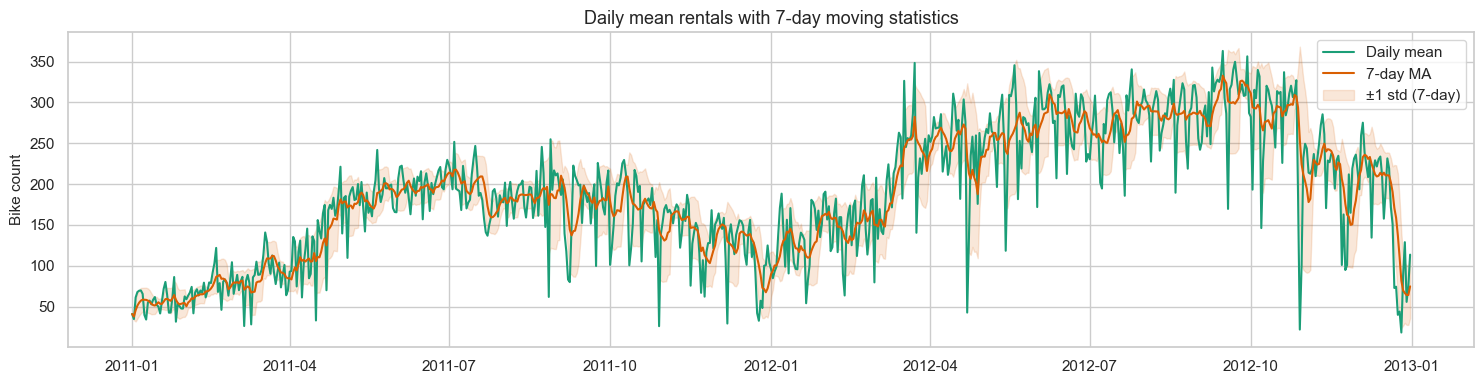

In [11]:

fig, ax = plt.subplots(figsize=(15, 4))
daily_mean = data['y'].resample('D').mean()
ax.plot(daily_mean.index, daily_mean.values, label='Daily mean', color='#1b9e77')
ax.plot(daily_mean.index, daily_mean.rolling(window=7, min_periods=1).mean(), label='7-day MA', color='#d95f02')
ax.fill_between(daily_mean.index,
                daily_mean.rolling(window=7, min_periods=1).mean() + daily_mean.rolling(window=7, min_periods=1).std(),
                daily_mean.rolling(window=7, min_periods=1).mean() - daily_mean.rolling(window=7, min_periods=1).std(),
                color='#d95f02', alpha=0.15, label='±1 std (7-day)')
ax.set_title('Daily mean rentals with 7-day moving statistics')
ax.set_ylabel('Bike count')
ax.legend()
plt.tight_layout()
plt.show()



#### Distributional Diagnostics

Weekday commuting patterns differ from weekend leisure demand. We therefore inspect histograms and exponential QQ-plots separately for working days and weekends to see how tails behave relative to an exponential reference distribution (often used in queueing and trading contexts).


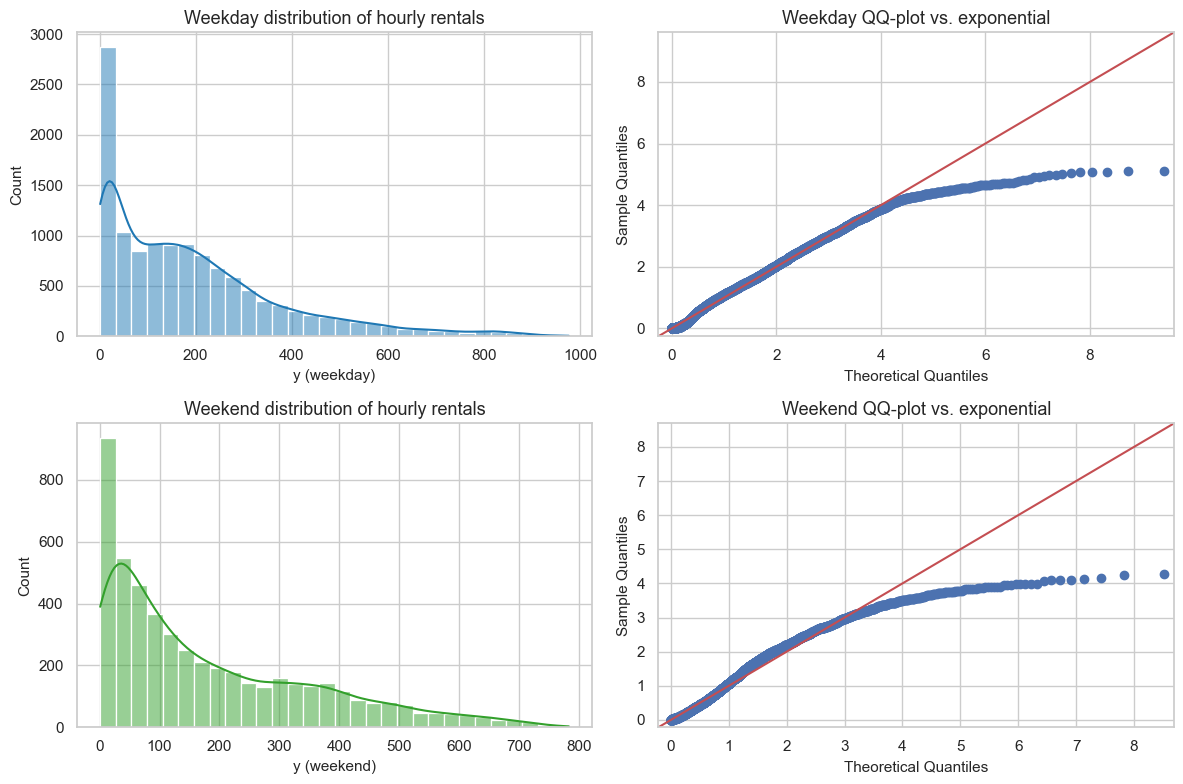

In [12]:

weekday_mask = data.index.dayofweek < 5
weekend_mask = ~weekday_mask

weekday_y = data.loc[weekday_mask, 'y']
weekend_y = data.loc[weekend_mask, 'y']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(weekday_y, bins=30, kde=True, ax=axes[0, 0], color='#1f78b4')
axes[0, 0].set_title('Weekday distribution of hourly rentals')
axes[0, 0].set_xlabel('y (weekday)')
qqplot(weekday_y, dist=stats.expon, fit=True, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Weekday QQ-plot vs. exponential')

sns.histplot(weekend_y, bins=30, kde=True, ax=axes[1, 0], color='#33a02c')
axes[1, 0].set_title('Weekend distribution of hourly rentals')
axes[1, 0].set_xlabel('y (weekend)')
qqplot(weekend_y, dist=stats.expon, fit=True, line='45', ax=axes[1, 1])
axes[1, 1].set_title('Weekend QQ-plot vs. exponential')

plt.tight_layout()
plt.show()



## 2. Stationarity, Decomposition, and Classical Forecasting

A stochastic process $ \{X_t\} $ is *weakly stationary* if:

$$
E[X_t] = \mu, \quad \text{Var}(X_t) = \sigma^2, \quad \text{and} \quad \text{Cov}(X_t, X_{t+h}) = \gamma(h)
$$

i.e. mean and variance do not depend on $ t $ and autocovariance depends only on the lag $ h $.

Why it matters:

- Classical ARIMA models assume stationarity (possibly after differencing).
- Hypothesis tests (e.g. Augmented Dickey-Fuller) rely on this assumption for valid inference.
- Decomposition into trend + seasonality + residual requires appreciating which component drives non-stationarity.

A simple differencing operator $ \nabla^d X_t = X_t - X_{t-d} $ is often enough to render a series stationary.


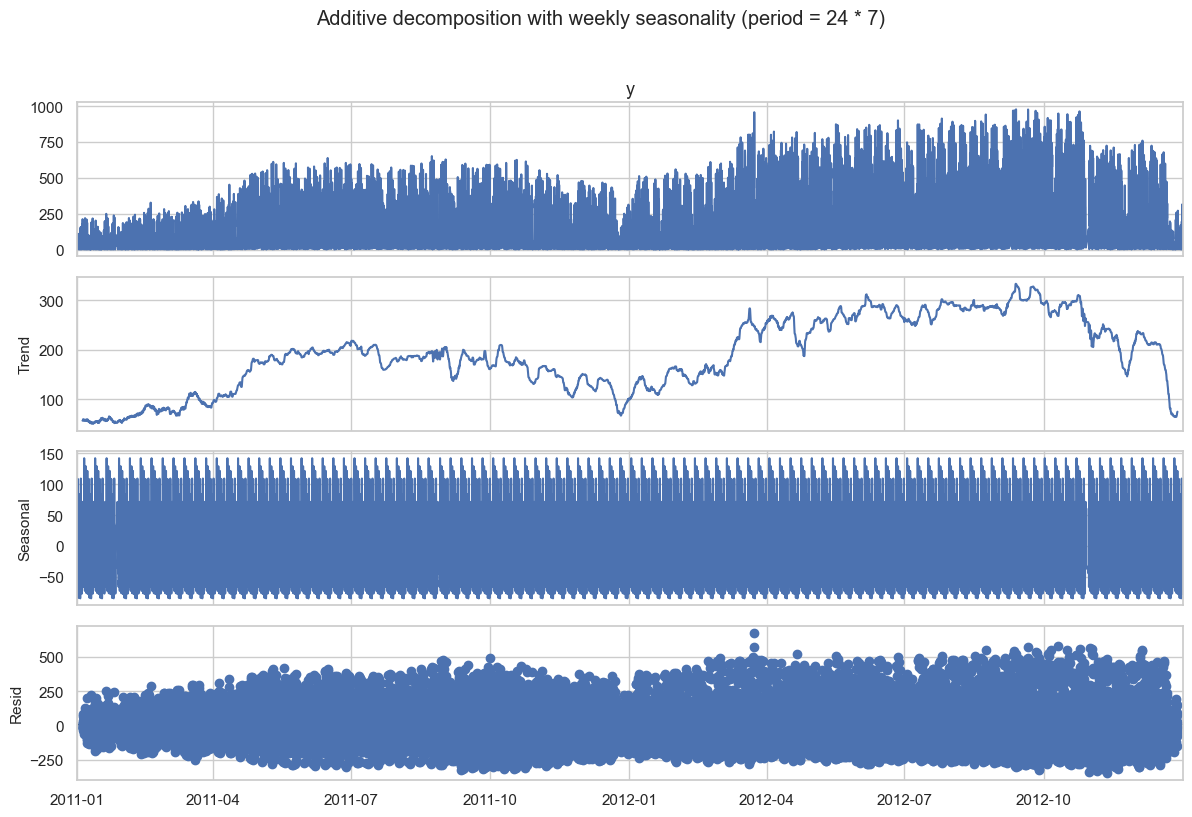

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
weekly_decomp = seasonal_decompose(data['y'], model='additive', period=24 * 7)
fig = weekly_decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Additive decomposition with weekly seasonality (period = 24 * 7)', y=1.02)
plt.tight_layout()
plt.show()


In [14]:
"""
stl_weekly = STL(data['y'], period=24 * 7, seasonal=169, trend=365, robust=True).fit()
stl_fig = stl_weekly.plot()
stl_fig.set_size_inches(12, 8)
plt.suptitle('STL decomposition with weekly seasonality and smooth trend', y=1.02)
plt.tight_layout()
plt.show()
"""

"\nstl_weekly = STL(data['y'], period=24 * 7, seasonal=169, trend=365, robust=True).fit()\nstl_fig = stl_weekly.plot()\nstl_fig.set_size_inches(12, 8)\nplt.suptitle('STL decomposition with weekly seasonality and smooth trend', y=1.02)\nplt.tight_layout()\nplt.show()\n"

c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\stl\mstl.py:218: UserWarning: A period(s) is larger than half the length of time series. Removing these period(s).
  warnings.warn(


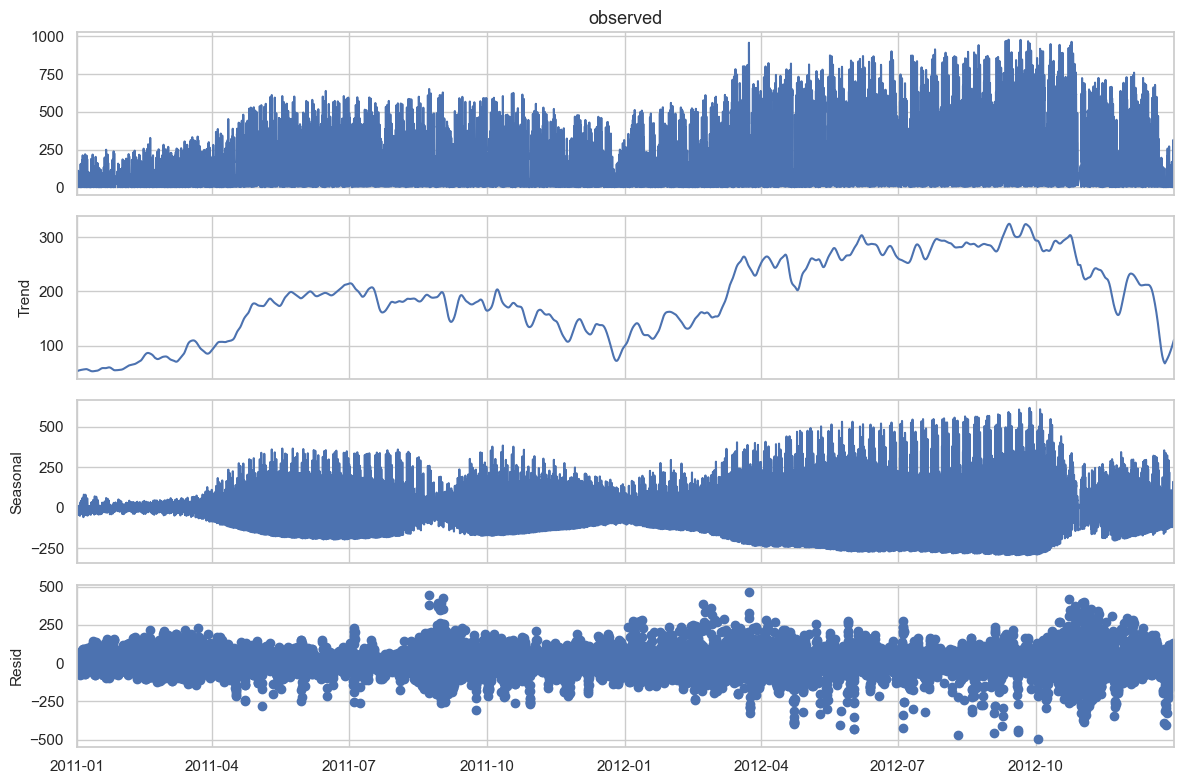

In [15]:
from statsmodels.tsa.seasonal import MSTL
import matplotlib.pyplot as plt

# hourly data: weekly=24*7=168, yearly≈24*365
res = MSTL(data['y'], periods=(24*7, 24*365)).fit()
fig = res.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [16]:

print('Augmented Dickey-Fuller test on original series:')
adf_stat, p_value, _, _, critical_values, _ = adfuller(data['y'])
print(f'ADF statistic = {adf_stat:.3f}, p-value = {p_value:.4f}')
print('Critical values:', critical_values)

diff_series = data['y'].diff().dropna()
print('Augmented Dickey-Fuller test on first difference:')
adf_stat, p_value, _, _, critical_values, _ = adfuller(diff_series)
print(f'ADF statistic = {adf_stat:.3f}, p-value = {p_value:.4f}')
print('Critical values:', critical_values)


Augmented Dickey-Fuller test on original series:
ADF statistic = -6.823, p-value = 0.0000
Critical values: {'1%': np.float64(-3.430727265144117), '5%': np.float64(-2.8617067365231246), '10%': np.float64(-2.5668587495404225)}
Augmented Dickey-Fuller test on first difference:
ADF statistic = -30.092, p-value = 0.0000
Critical values: {'1%': np.float64(-3.430727330450937), '5%': np.float64(-2.8617067653843655), '10%': np.float64(-2.5668587649028334)}


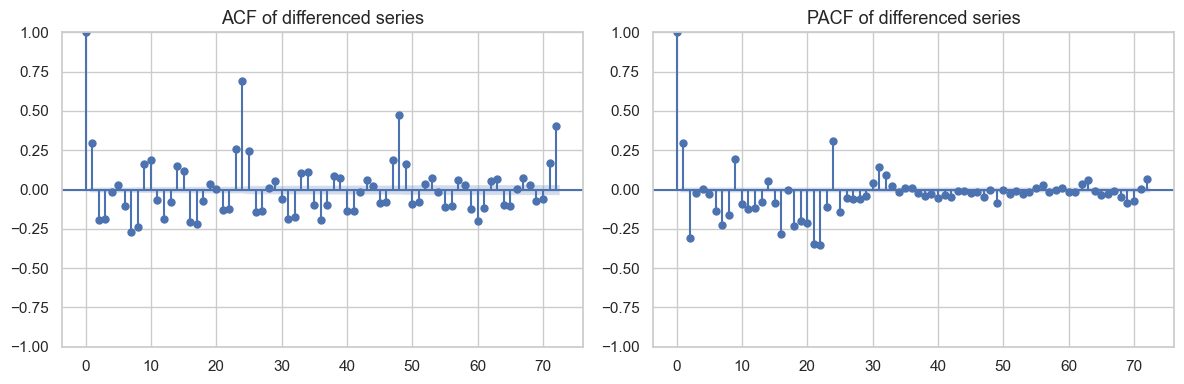

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(diff_series, ax=axes[0], lags=72)
axes[0].set_title('ACF of differenced series')
plot_pacf(diff_series, ax=axes[1], lags=72, method='ywm')
axes[1].set_title('PACF of differenced series')
plt.tight_layout()
plt.show()



### STL Decomposition for Multiple Seasonalities

STL (Seasonal-Trend decomposition using Loess) handles multiple seasonal patterns more gracefully compared to classical decomposition.


In [18]:
"""
stl = STL(data['y'], period=24*7, robust=True).fit()
stl.plot()
plt.suptitle('STL decomposition (weekly seasonality)', y=1.02)
plt.tight_layout()
plt.show()
"""

"\nstl = STL(data['y'], period=24*7, robust=True).fit()\nstl.plot()\nplt.suptitle('STL decomposition (weekly seasonality)', y=1.02)\nplt.tight_layout()\nplt.show()\n"


### SARIMAX Baseline

We fit a seasonal ARIMA model as a classical benchmark. Parameters are chosen based on ACF/PACF inspection (1 seasonal differencing, weekly seasonality).


In [19]:
"""
train_start = '2012-04-01 00:00:00'
train_end = '2012-09-30 23:00:00'
train_series = data.loc[train_start:train_end, 'y']
# Keep the backtest manageable: evaluate on the first four weeks of Q4 2012
backtest_end = '2012-10-31 23:00:00'
test_series = data.loc['2012-10-01 00:00:00':backtest_end, 'y']

print(f'Training samples: {len(train_series)}, Test samples: {len(test_series)}')

sarimax_model = SARIMAX(train_series,
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 24 * 7),
                        trend='c',
                        enforce_stationarity=False,
                        enforce_invertibility=False)
sarimax_result = sarimax_model.fit(disp=False)
print('Model fitted.')

rolling_predictions = []
updated_result = sarimax_result
for timestamp, actual in test_series.items():
    forecast = updated_result.forecast(steps=1)
    rolling_predictions.append(forecast.iloc[0])
    updated_result = updated_result.append(endog=pd.Series([actual], index=[timestamp]), refit=False)

pred_series = pd.Series(rolling_predictions, index=test_series.index, name='forecast')
metrics = evaluate_metrics(test_series.values, pred_series.values)
print('Walk-forward SARIMAX metrics on test window:', metrics)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_series.iloc[-30 * 24:], label='Training (last 30 days)', color='#1f77b4', alpha=0.6)
ax.plot(test_series, label='Actual (test)', color='#2ca02c')
ax.plot(pred_series, label='SARIMAX walk-forward forecast', color='#d62728')
ax.set_title('Walk-forward SARIMAX backtest (Oct 2012, one-hour horizon)')
ax.legend()
plt.tight_layout()
plt.show()
"""

"\ntrain_start = '2012-04-01 00:00:00'\ntrain_end = '2012-09-30 23:00:00'\ntrain_series = data.loc[train_start:train_end, 'y']\n# Keep the backtest manageable: evaluate on the first four weeks of Q4 2012\nbacktest_end = '2012-10-31 23:00:00'\ntest_series = data.loc['2012-10-01 00:00:00':backtest_end, 'y']\n\nprint(f'Training samples: {len(train_series)}, Test samples: {len(test_series)}')\n\nsarimax_model = SARIMAX(train_series,\n                        order=(1, 1, 1),\n                        seasonal_order=(1, 1, 1, 24 * 7),\n                        trend='c',\n                        enforce_stationarity=False,\n                        enforce_invertibility=False)\nsarimax_result = sarimax_model.fit(disp=False)\nprint('Model fitted.')\n\nrolling_predictions = []\nupdated_result = sarimax_result\nfor timestamp, actual in test_series.items():\n    forecast = updated_result.forecast(steps=1)\n    rolling_predictions.append(forecast.iloc[0])\n    updated_result = updated_result.append(

In [20]:
"""
data = data.asfreq("H")                     # give statsmodels the hourly freq
train_start = "2012-04-01 00:00:00"
train_end   = "2012-09-30 23:00:00"
backtest_end = "2012-10-31 23:00:00"

train_series = data.loc[train_start:train_end, "y"]
test_series  = data.loc["2012-10-01 00:00:00":backtest_end, "y"]

sarimax = SARIMAX(train_series,
                  order=(1,1,1),
                  seasonal_order=(1,1,1,24*7),
                  trend="c",
                  enforce_stationarity=False,
                  enforce_invertibility=False)

res = sarimax.fit(disp=False)

# Apply the filtered parameters to the whole (train+test) span in one pass
full_series = data.loc[train_start:backtest_end, "y"]
applied = sarimax.apply(full_series, refit=False)     # or sarimax.filter(res.params)

# 1-step-ahead (“true” walk-forward) forecasts for the test span
pred = applied.get_prediction(start=test_series.index[0], end=test_series.index[-1], dynamic=False)
pred_series = pred.predicted_mean
metrics = evaluate_metrics(test_series.values, pred_series.values)

print("Walk-forward SARIMAX metrics:", metrics)
"""

'\ndata = data.asfreq("H")                     # give statsmodels the hourly freq\ntrain_start = "2012-04-01 00:00:00"\ntrain_end   = "2012-09-30 23:00:00"\nbacktest_end = "2012-10-31 23:00:00"\n\ntrain_series = data.loc[train_start:train_end, "y"]\ntest_series  = data.loc["2012-10-01 00:00:00":backtest_end, "y"]\n\nsarimax = SARIMAX(train_series,\n                  order=(1,1,1),\n                  seasonal_order=(1,1,1,24*7),\n                  trend="c",\n                  enforce_stationarity=False,\n                  enforce_invertibility=False)\n\nres = sarimax.fit(disp=False)\n\n# Apply the filtered parameters to the whole (train+test) span in one pass\nfull_series = data.loc[train_start:backtest_end, "y"]\napplied = sarimax.apply(full_series, refit=False)     # or sarimax.filter(res.params)\n\n# 1-step-ahead (“true” walk-forward) forecasts for the test span\npred = applied.get_prediction(start=test_series.index[0], end=test_series.index[-1], dynamic=False)\npred_series = pred.p


## 3. Machine Learning vs. Deep Learning for Time Series

Unlike i.i.d. tabular data, time series require chronological splits to avoid leakage. Common strategies include:

- Single hold-out with a contiguous validation window.
- Rolling-origin evaluation or walk-forward validation.
- TimeSeriesSplit (expanding window) in scikit-learn.

In addition, we must engineer lagged features, seasonal indicators, and rolling statistics to provide algorithms with temporal context.


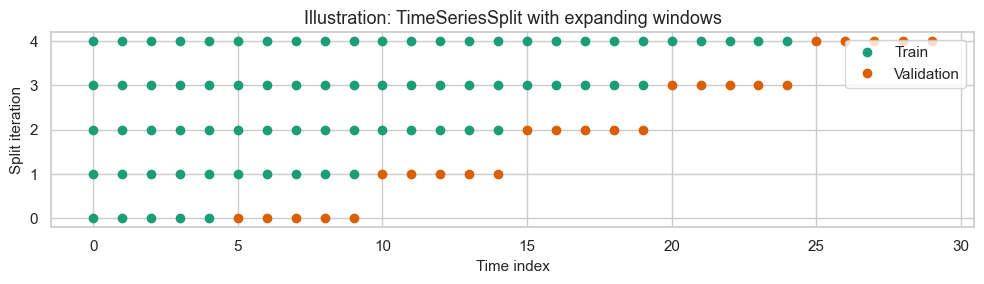

In [21]:

ts_split = TimeSeriesSplit(n_splits=5)
example_idx = list(range(30))

fig, ax = plt.subplots(figsize=(10, 3))
for i, (train_idx, test_idx) in enumerate(ts_split.split(example_idx)):
    ax.plot(train_idx, [i] * len(train_idx), color='#1b9e77', marker='o', linestyle='None', label='Train' if i == 0 else '')
    ax.plot(test_idx, [i] * len(test_idx), color='#d95f02', marker='o', linestyle='None', label='Validation' if i == 0 else '')
ax.set_title('Illustration: TimeSeriesSplit with expanding windows')
ax.set_xlabel('Time index')
ax.set_ylabel('Split iteration')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()



## 4. Feature Engineering for Multi-horizon Forecasts

We prepare a feature-rich DataFrame containing:

- Lagged targets (1-4 hours, 24 hours, 168 hours).
- Aggregations representing "same hour yesterday/week" averaged over a 4-hour window.
- Exponential moving averages (EMA) with spans of 6, 12, and 24 hours.
- Calendar features (hour, day of week, month, weekend flag) and their sine/cosine encodings.
- Weather covariates provided in the original dataset.

The helper functions below generate feature matrices for horizons $ h \in \{1,2,3\} $ by shifting the target $ y_{t+h} $.


In [22]:

feature_frames: Dict[int, Dict[str, object]] = {}
for horizon in HORIZONS:
    frame, feature_cols, target_col = create_time_features(data, horizon)
    feature_frames[horizon] = {
        'frame': frame,
        'feature_cols': feature_cols,
        'target_col': target_col,
    }
    print(f'Horizon +{horizon}h: {len(frame)} rows, {len(feature_cols)} features')


Horizon +1h: 17207 rows, 26 features
Horizon +2h: 17206 rows, 26 features
Horizon +3h: 17205 rows, 26 features
Horizon +4h: 17204 rows, 26 features


In [23]:
feature_frames[1]['frame'][feature_frames[1]['feature_cols'] + [feature_frames[1]['target_col']]].head()

,atemp,dayofweek,ema_12,ema_24,ema_6,holiday,hour,hour_cos,hour_sin,hum,...,lag_3,lag_4,month,season,temp,weather,weekofyear,windspeed,workingday,target_t+1
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-08 10:00:00+00:00,0.1970,5,27.578358,38.631114,27.297916,0,10,-0.866025,5.000000e-01,0.80,...,9.0,2.0,1,1,0.18,2,1,0.1642,0,62.0
2011-01-08 11:00:00+00:00,0.1818,5,32.873995,40.500625,37.212797,0,11,-0.965926,2.588190e-01,0.69,...,15.0,9.0,1,1,0.20,2,1,0.3881,0,98.0
2011-01-08 12:00:00+00:00,0.1818,5,42.893381,45.100575,54.580570,0,12,-1.000000,1.224647e-16,0.59,...,20.0,15.0,1,1,0.20,2,1,0.3582,0,102.0
2011-01-08 13:00:00+00:00,0.1818,5,51.986707,49.652529,68.128978,0,13,-0.965926,-2.588190e-01,0.44,...,61.0,20.0,1,1,0.20,1,1,0.3284,0,95.0
2011-01-08 14:00:00+00:00,0.1667,5,58.604137,53.280327,75.806413,0,14,-0.866025,-5.000000e-01,0.32,...,62.0,61.0,1,1,0.20,1,1,0.4925,0,74.0



### Example of Engineered Features (1-hour Horizon)


In [24]:
feature_frames[4]['frame'][feature_frames[4]['feature_cols'] + [feature_frames[4]['target_col']]].head()

,atemp,dayofweek,ema_12,ema_24,ema_6,holiday,hour,hour_cos,hour_sin,hum,...,lag_3,lag_4,month,season,temp,weather,weekofyear,windspeed,workingday,target_t+4
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-08 10:00:00+00:00,0.1970,5,27.578358,38.631114,27.297916,0,10,-0.866025,5.000000e-01,0.80,...,9.0,2.0,1,1,0.18,2,1,0.1642,0,95.0
2011-01-08 11:00:00+00:00,0.1818,5,32.873995,40.500625,37.212797,0,11,-0.965926,2.588190e-01,0.69,...,15.0,9.0,1,1,0.20,2,1,0.3881,0,74.0
2011-01-08 12:00:00+00:00,0.1818,5,42.893381,45.100575,54.580570,0,12,-1.000000,1.224647e-16,0.59,...,20.0,15.0,1,1,0.20,2,1,0.3582,0,76.0
2011-01-08 13:00:00+00:00,0.1818,5,51.986707,49.652529,68.128978,0,13,-0.965926,-2.588190e-01,0.44,...,61.0,20.0,1,1,0.20,1,1,0.3284,0,69.0
2011-01-08 14:00:00+00:00,0.1667,5,58.604137,53.280327,75.806413,0,14,-0.866025,-5.000000e-01,0.32,...,62.0,61.0,1,1,0.20,1,1,0.4925,0,55.0



### Train / Validation / Test Split

We use chronological splits: 70% train, 15% validation, 15% test.


In [25]:

splits: Dict[int, SplitData] = {}
for horizon, payload in feature_frames.items():
    splits[horizon] = split_time_series(payload['frame'], payload['feature_cols'], payload['target_col'])
    print(
        'Horizon +{0}h -> train {1}, val {2}, test {3}'.format(
            horizon,
            len(splits[horizon].y_train),
            len(splits[horizon].y_val),
            len(splits[horizon].y_test),
        )
    )


Horizon +1h -> train 12044, val 2581, test 2582
Horizon +2h -> train 12044, val 2581, test 2581
Horizon +3h -> train 12043, val 2581, test 2581
Horizon +4h -> train 12042, val 2581, test 2581



## 5. Gradient Boosting Models (XGBoost & CatBoost)

Tree ensembles handle non-linearities, interactions, and mixed-scale features gracefully. We use Optuna for light hyperparameter tuning on the validation split for each horizon.


In [26]:

from functools import partial


def evaluate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Return RMSE, MAE, and R² metrics."""
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'rmse': rmse, 'mae': mae, 'r2': r2}


In [29]:
if 'HAS_CATBOOST' not in globals():
    HAS_CATBOOST = False

In [30]:
results: List[Dict[str, object]] = []
model_store: Dict[Tuple[str, int], object] = {}

for horizon, split in splits.items():
    print('=== Horizon +{0}h | XGBoost tuning ==='.format(horizon))
    best_xgb_params = tune_xgb(split, horizon, n_trials=15)
    xgb_model = train_xgb(split, best_xgb_params)
    xgb_preds = xgb_model.predict(split.X_test)
    metrics = evaluate_metrics(split.y_test, xgb_preds)
    metrics.update({'model': 'XGBoost', 'horizon': horizon})
    results.append(metrics)
    model_store[('XGBoost', horizon)] = xgb_model
    print('Test metrics:', metrics)

    if HAS_CATBOOST:
        print('=== Horizon +{0}h | CatBoost tuning ==='.format(horizon))
        cat_columns = get_categorical_columns(split.feature_names)
        best_cat_params = tune_catboost(split, cat_columns, horizon, n_trials=15)
        cat_model = train_catboost(split, best_cat_params, cat_columns)
        test_df = prepare_catboost_frame(split.X_test, split.feature_names, cat_columns)
        cat_preds = cat_model.predict(test_df)
        metrics = evaluate_metrics(split.y_test, cat_preds)
        metrics.update({'model': 'CatBoost', 'horizon': horizon})
        results.append(metrics)
        model_store[('CatBoost', horizon)] = (cat_model, cat_columns)
        print('Test metrics:', metrics)
    else:
        print('CatBoost helpers unavailable; skipping CatBoost for horizon +{0}h'.format(horizon))


=== Horizon +1h | XGBoost tuning ===
Test metrics: {'rmse': 53.38979819080496, 'mae': 35.63754979394648, 'r2': 0.9377313222143515, 'model': 'XGBoost', 'horizon': 1}
=== Horizon +1h | CatBoost tuning ===
Test metrics: {'rmse': 48.607229421480994, 'mae': 31.4170781868579, 'r2': 0.9483875090102784, 'model': 'CatBoost', 'horizon': 1}
=== Horizon +2h | XGBoost tuning ===
Test metrics: {'rmse': 59.92978414580155, 'mae': 38.146684840929915, 'r2': 0.9213182908843722, 'model': 'XGBoost', 'horizon': 2}
=== Horizon +2h | CatBoost tuning ===
Test metrics: {'rmse': 61.70445112639441, 'mae': 40.79462315469323, 'r2': 0.9165893808038601, 'model': 'CatBoost', 'horizon': 2}
=== Horizon +3h | XGBoost tuning ===
Test metrics: {'rmse': 70.82606747945691, 'mae': 46.15133653867503, 'r2': 0.8901058394686852, 'model': 'XGBoost', 'horizon': 3}
=== Horizon +3h | CatBoost tuning ===
Test metrics: {'rmse': 66.72361345402224, 'mae': 43.05896560808881, 'r2': 0.9024679228407742, 'model': 'CatBoost', 'horizon': 3}
===


## 6. Feed-forward Neural Network (PyTorch)

Before feeding data into dense networks, we standardise the features using statistics from the training set only.


In [31]:

class FeedForwardNet(nn.Module):
    """Simple fully connected neural network with four hidden layers."""

    def __init__(self, input_dim: int):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


def prepare_scaled_tensors(split: SplitData) -> Tuple[TensorDataset, TensorDataset, TensorDataset, StandardScaler]:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(split.X_train)
    X_val = scaler.transform(split.X_val)
    X_test = scaler.transform(split.X_test)
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(split.y_train, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(split.y_val, dtype=torch.float32))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(split.y_test, dtype=torch.float32))
    return train_ds, val_ds, test_ds, scaler


def train_mlp(train_ds: TensorDataset, val_ds: TensorDataset, input_dim: int, epochs: int = 40, lr: float = 1e-3) -> Tuple[FeedForwardNet, List[float]]:
    model = FeedForwardNet(input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

    best_val = float('inf')
    best_state = None
    history = []

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb).squeeze()
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_losses = []
            for xb, yb in val_loader:
                preds = model(xb).squeeze()
                val_losses.append(criterion(preds, yb).item())
            val_loss = float(np.mean(val_losses))
            history.append(val_loss)
            if val_loss < best_val:
                best_val = val_loss
                best_state = model.state_dict()
        if epoch % 10 == 0:
            print(f'Epoch {epoch:03d} | Val MSE: {val_loss:.4f}')

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [32]:

for horizon, split in splits.items():
    train_ds, val_ds, test_ds, scaler = prepare_scaled_tensors(split)
    model, history = train_mlp(train_ds, val_ds, input_dim=train_ds.tensors[0].shape[1], epochs=40, lr=1e-3)
    model_store[(f'MLP', horizon)] = (model, scaler)

    model.eval()
    with torch.no_grad():
        X_test_scaled = torch.tensor(scaler.transform(split.X_test), dtype=torch.float32)
        preds = model(X_test_scaled).squeeze().numpy()

    metrics = evaluate_metrics(split.y_test, preds)
    metrics.update({'model': 'FeedForwardNN', 'horizon': horizon})
    results.append(metrics)
    print(f'Horizon +{horizon}h | MLP metrics: {metrics}')


Epoch 000 | Val MSE: 102366.3097
Epoch 010 | Val MSE: 5144.1104
Epoch 020 | Val MSE: 3424.6864
Epoch 030 | Val MSE: 3561.3115
Horizon +1h | MLP metrics: {'rmse': 57.22325060415595, 'mae': 36.59581633278051, 'r2': 0.9284683678420014, 'model': 'FeedForwardNN', 'horizon': 1}
Epoch 000 | Val MSE: 106257.6690
Epoch 010 | Val MSE: 7320.0336
Epoch 020 | Val MSE: 5348.7874
Epoch 030 | Val MSE: 5256.4687
Horizon +2h | MLP metrics: {'rmse': 74.30886958344233, 'mae': 48.23701266446164, 'r2': 0.8790322319900769, 'model': 'FeedForwardNN', 'horizon': 2}
Epoch 000 | Val MSE: 101653.0298
Epoch 010 | Val MSE: 6332.9681
Epoch 020 | Val MSE: 5062.4310
Epoch 030 | Val MSE: 6104.0613
Horizon +3h | MLP metrics: {'rmse': 79.34597916941902, 'mae': 51.52994458839811, 'r2': 0.8620765201597722, 'model': 'FeedForwardNN', 'horizon': 3}
Epoch 000 | Val MSE: 116117.0511
Epoch 010 | Val MSE: 7631.5906
Epoch 020 | Val MSE: 6647.7722
Epoch 030 | Val MSE: 6779.4242
Horizon +4h | MLP metrics: {'rmse': 87.37910800715197, 


## 7. LSTM for Sequence Modelling

LSTMs shine when the order of observations matters and when long-term dependencies exist. We build supervised samples using a sliding window of 24 hours and predict 1-3 hours ahead simultaneously.


In [41]:

WINDOW = 24

def create_sequence_data(series: np.ndarray, window: int, horizons: Iterable[int]) -> Tuple[np.ndarray, np.ndarray]:
    max_h = max(horizons)
    X, y = [], []
    for i in range(len(series) - window - max_h + 1):
        X.append(series[i:i+window])
        y.append([series[i+window + h - 1] for h in horizons])
    return np.array(X), np.array(y)


series = data['y'].values
train_cut = int(len(series) * 0.7)
val_cut = int(len(series) * 0.85)
scaler_seq = MinMaxScaler()
scaler_seq.fit(series[:train_cut].reshape(-1, 1))
series_scaled = scaler_seq.transform(series.reshape(-1, 1)).flatten()

X_seq, y_seq = create_sequence_data(series_scaled, WINDOW, HORIZONS)

train_end = train_cut - WINDOW - max(HORIZONS) + 1
val_end = val_cut - WINDOW - max(HORIZONS) + 1

X_train_seq, y_train_seq = X_seq[:train_end], y_seq[:train_end]
X_val_seq, y_val_seq = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test_seq, y_test_seq = X_seq[val_end:], y_seq[val_end:]

train_ds_seq = TensorDataset(torch.tensor(X_train_seq[:, :, None], dtype=torch.float32), torch.tensor(y_train_seq, dtype=torch.float32))
val_ds_seq = TensorDataset(torch.tensor(X_val_seq[:, :, None], dtype=torch.float32), torch.tensor(y_val_seq, dtype=torch.float32))
test_ds_seq = TensorDataset(torch.tensor(X_test_seq[:, :, None], dtype=torch.float32), torch.tensor(y_test_seq, dtype=torch.float32))


In [42]:

class LSTMRegressor(nn.Module):
    def __init__(self, hidden_size: int = 64, num_layers: int = 2, horizons: int = 3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


def train_lstm(train_ds: TensorDataset, val_ds: TensorDataset, epochs: int = 40, lr: float = 1e-3) -> LSTMRegressor:
    model = LSTMRegressor(horizons=len(HORIZONS))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

    best_val = float('inf')
    best_state = None
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_losses = [criterion(model(xb), yb).item() for xb, yb in val_loader]
            val_loss = float(np.mean(val_losses))
            if val_loss < best_val:
                best_val = val_loss
                best_state = model.state_dict()
        if epoch % 10 == 0:
            print(f'LSTM epoch {epoch:03d} | Val MSE: {val_loss:.4f}')
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

lstm_model = train_lstm(train_ds_seq, val_ds_seq, epochs=50, lr=1e-3)
model_store[('LSTM', 'multi')] = lstm_model


LSTM epoch 000 | Val MSE: 0.0700
LSTM epoch 010 | Val MSE: 0.0076
LSTM epoch 020 | Val MSE: 0.0064
LSTM epoch 030 | Val MSE: 0.0057
LSTM epoch 040 | Val MSE: 0.0055


In [43]:

lstm_model.eval()
with torch.no_grad():
    preds_scaled = lstm_model(torch.tensor(X_test_seq[:, :, None], dtype=torch.float32)).numpy()

preds = scaler_seq.inverse_transform(preds_scaled)
y_test_multi = scaler_seq.inverse_transform(y_test_seq)

lstm_predictions_by_horizon = {}
for idx, horizon in enumerate(HORIZONS):
    test_idx = feature_frames[horizon]['frame'].iloc[len(splits[horizon].y_train) + len(splits[horizon].y_val):].index
    lstm_pred = preds[:, idx]
    lstm_true = y_test_multi[:, idx]
    common_len = min(len(test_idx), len(lstm_pred))
    aligned_idx = test_idx[-common_len:]
    lstm_pred_series = pd.Series(lstm_pred[-common_len:], index=aligned_idx)
    lstm_true_series = pd.Series(lstm_true[-common_len:], index=aligned_idx)
    lstm_predictions_by_horizon[horizon] = lstm_pred_series
    metrics = evaluate_metrics(lstm_true_series.values, lstm_pred_series.values)
    metrics.update({'model': 'LSTM', 'horizon': horizon})
    results.append(metrics)
    print(f'LSTM horizon +{horizon}h metrics: {metrics}')


LSTM horizon +1h metrics: {'rmse': 51.93084264774133, 'mae': 31.699062007663326, 'r2': 0.9412940720460966, 'model': 'LSTM', 'horizon': 1}
LSTM horizon +2h metrics: {'rmse': 66.73844662209716, 'mae': 40.77772335804701, 'r2': 0.9030320845309809, 'model': 'LSTM', 'horizon': 2}
LSTM horizon +3h metrics: {'rmse': 75.49943100513902, 'mae': 47.34418526312631, 'r2': 0.8754915520490659, 'model': 'LSTM', 'horizon': 3}
LSTM horizon +4h metrics: {'rmse': 79.57612180384075, 'mae': 51.17437056608207, 'r2': 0.8612752670352277, 'model': 'LSTM', 'horizon': 4}



## 8. Ensemble of Tree, Dense NN, and LSTM

We build a simple average ensemble combining the strongest tree-based model (XGBoost), the feed-forward network, and the LSTM. Ensembles often stabilise predictions by mixing complementary biases.


In [44]:

lstm_model.eval()
with torch.no_grad():
    val_preds_scaled = lstm_model(torch.tensor(X_val_seq[:, :, None], dtype=torch.float32)).numpy()
    test_preds_scaled = lstm_model(torch.tensor(X_test_seq[:, :, None], dtype=torch.float32)).numpy()

val_preds = scaler_seq.inverse_transform(val_preds_scaled)
val_targets = scaler_seq.inverse_transform(y_val_seq)
test_preds = scaler_seq.inverse_transform(test_preds_scaled)
test_targets = scaler_seq.inverse_transform(y_test_seq)

lstm_val_predictions: Dict[int, pd.Series] = {}
lstm_test_predictions: Dict[int, pd.Series] = {}

for idx, horizon in enumerate(HORIZONS):
    split = splits[horizon]
    frame = feature_frames[horizon]['frame']
    train_len = len(split.y_train)
    val_len_total = len(split.y_val)
    val_idx = frame.iloc[train_len:train_len + val_len_total].index
    test_idx = frame.iloc[train_len + val_len_total:].index

    val_pred = val_preds[:, idx]
    val_true = val_targets[:, idx]
    val_len = min(len(val_idx), len(val_pred))
    val_idx_aligned = val_idx[-val_len:]
    val_pred_series = pd.Series(val_pred[-val_len:], index=val_idx_aligned)
    val_true_series = pd.Series(val_true[-val_len:], index=val_idx_aligned)
    lstm_val_predictions[horizon] = val_pred_series

    test_pred = test_preds[:, idx]
    test_true = test_targets[:, idx]
    test_len = min(len(test_idx), len(test_pred))
    test_idx_aligned = test_idx[-test_len:]
    test_pred_series = pd.Series(test_pred[-test_len:], index=test_idx_aligned)
    test_true_series = pd.Series(test_true[-test_len:], index=test_idx_aligned)
    lstm_test_predictions[horizon] = test_pred_series

    metrics = evaluate_metrics(test_true_series.values, test_pred_series.values)
    metrics.update({'model': 'LSTM', 'horizon': horizon})
    results.append(metrics)
    print(f'LSTM horizon +{horizon}h metrics: {metrics}')


Ensemble horizon +1h metrics: {'rmse': 102.51378599004009, 'mae': 71.55209364810717, 'r2': 0.770428679968363, 'model': 'Ensemble_XGB+MLP+LSTM', 'horizon': 1} (weights: xgb=0.34, mlp=0.32, lstm=0.35)
Ensemble horizon +2h metrics: {'rmse': 94.61836404582087, 'mae': 63.50261926251481, 'r2': 0.8038721679617005, 'model': 'Ensemble_XGB+MLP+LSTM', 'horizon': 2} (weights: xgb=0.37, mlp=0.30, lstm=0.33)
Ensemble horizon +3h metrics: {'rmse': 81.14389530949113, 'mae': 52.12320167504046, 'r2': 0.8557552343538024, 'model': 'Ensemble_XGB+MLP+LSTM', 'horizon': 3} (weights: xgb=0.35, mlp=0.32, lstm=0.33)
Ensemble horizon +4h metrics: {'rmse': 70.67997607870453, 'mae': 45.11290651612945, 'r2': 0.8905587245345158, 'model': 'Ensemble_XGB+MLP+LSTM', 'horizon': 4} (weights: xgb=0.37, mlp=0.30, lstm=0.33)



## 9. AutoML Benchmark (FLAML)

FLAML automatically explores lightweight models / hyperparameters under a time budget. We compare its results against our custom models.


In [45]:

automl_results: Dict[int, Tuple[AutoML, np.ndarray]] = {}
TIME_BUDGET = 60  # seconds per horizon

for horizon, split in splits.items():
    automl = AutoML()
    automl.fit(
        X_train=np.vstack([split.X_train, split.X_val]),
        y_train=np.concatenate([split.y_train, split.y_val]),
        task='regression',
        time_budget=TIME_BUDGET,
        metric='rmse',
        eval_method='cv',
        n_splits=3,
        seed=RANDOM_SEED,
        verbose=False,
    )
    preds = automl.predict(split.X_test)
    automl_results[horizon] = (automl, preds)
    metrics = evaluate_metrics(split.y_test, preds)
    metrics.update({'model': f'FLAML_AutoML({automl.best_estimator})', 'horizon': horizon})
    results.append(metrics)
    print(f'AutoML horizon +{horizon}h metrics: {metrics}')


c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation

AutoML horizon +1h metrics: {'rmse': 48.66853879981126, 'mae': 31.303689825501717, 'r2': 0.9482572269352026, 'model': 'FLAML_AutoML(catboost)', 'horizon': 1}


c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation

AutoML horizon +2h metrics: {'rmse': 60.923352009143585, 'mae': 38.51851163729114, 'r2': 0.9186877574933479, 'model': 'FLAML_AutoML(catboost)', 'horizon': 2}


c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation

AutoML horizon +3h metrics: {'rmse': 67.99442286592614, 'mae': 43.146084030552636, 'r2': 0.8987173765972558, 'model': 'FLAML_AutoML(catboost)', 'horizon': 3}


c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation

AutoML horizon +4h metrics: {'rmse': 69.52338306744034, 'mae': 44.00077462099704, 'r2': 0.894111169355753, 'model': 'FLAML_AutoML(catboost)', 'horizon': 4}


In [ ]:

stacked_results = []
stacked_predictions: Dict[int, np.ndarray] = {}
stack_models: Dict[int, XGBRegressor] = {}

for horizon, split in splits.items():
    y_val_meta = split.y_val
    y_test_meta = split.y_test

    feature_blocks_val = [split.X_val]
    feature_blocks_test = [split.X_test]

    xgb_model = model_store[('XGBoost', horizon)]
    xgb_val_pred = xgb_model.predict(split.X_val)
    xgb_test_pred = xgb_model.predict(split.X_test)
    feature_blocks_val.append(xgb_val_pred.reshape(-1, 1))
    feature_blocks_test.append(xgb_test_pred.reshape(-1, 1))

    if HAS_CATBOOST and ('CatBoost', horizon) in model_store:
        cat_model, cat_columns = model_store[('CatBoost', horizon)]
        val_df = prepare_catboost_frame(split.X_val, split.feature_names, cat_columns)
        test_df = prepare_catboost_frame(split.X_test, split.feature_names, cat_columns)
        cat_val_pred = cat_model.predict(val_df)
        cat_test_pred = cat_model.predict(test_df)
        feature_blocks_val.append(cat_val_pred.reshape(-1, 1))
        feature_blocks_test.append(cat_test_pred.reshape(-1, 1))

    mlp_model, mlp_scaler = model_store[('MLP', horizon)]
    mlp_model.eval()
    with torch.no_grad():
        mlp_val_pred = mlp_model(torch.tensor(mlp_scaler.transform(split.X_val), dtype=torch.float32)).squeeze().numpy()
        mlp_test_pred = mlp_model(torch.tensor(mlp_scaler.transform(split.X_test), dtype=torch.float32)).squeeze().numpy()
    feature_blocks_val.append(mlp_val_pred.reshape(-1, 1))
    feature_blocks_test.append(mlp_test_pred.reshape(-1, 1))

    if horizon in lstm_val_predictions and horizon in lstm_test_predictions:
        lstm_val_series = lstm_val_predictions[horizon]
        lstm_test_series = lstm_test_predictions[horizon]
        common_val_len = min(len(split.y_val), len(lstm_val_series))
        common_test_len = min(len(split.y_test), len(lstm_test_series))
        lstm_val_array = lstm_val_series.values[-common_val_len:].reshape(-1, 1)
        lstm_test_array = lstm_test_series.values[-common_test_len:].reshape(-1, 1)
        if common_val_len != len(split.y_val):
            y_val_meta = split.y_val[-common_val_len:]
            feature_blocks_val = [block[-common_val_len:] if block.ndim == 1 else block[-common_val_len:, :] for block in feature_blocks_val]
        if common_test_len != len(split.y_test):
            y_test_meta = split.y_test[-common_test_len:]
            feature_blocks_test = [block[-common_test_len:] if block.ndim == 1 else block[-common_test_len:, :] for block in feature_blocks_test]
        feature_blocks_val.append(lstm_val_array)
        feature_blocks_test.append(lstm_test_array)

    X_val_meta = np.hstack([block if block.ndim == 2 else block.reshape(-1, 1) for block in feature_blocks_val])
    X_test_meta = np.hstack([block if block.ndim == 2 else block.reshape(-1, 1) for block in feature_blocks_test])

    meta_model = XGBRegressor(
        objective='reg:squarederror',
        random_state=RANDOM_SEED,
        tree_method='hist',
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
    )
    meta_model.fit(X_val_meta, y_val_meta)
    meta_preds = meta_model.predict(X_test_meta)
    stacked_predictions[horizon] = meta_preds
    stack_models[horizon] = meta_model

    metrics = evaluate_metrics(y_test_meta, meta_preds)
    metrics.update({'model': 'Stacked_XGB', 'horizon': horizon})
    results.append(metrics)
    stacked_results.append(metrics)
    print(f'Stacked XGB horizon +{horizon}h metrics: {metrics}')



## 10. Result Synthesis

The table below consolidates RMSE, MAE, and R² for all models across horizons. Lower RMSE/MAE and higher R² indicate better performance.


In [46]:

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['horizon', 'rmse']).reset_index(drop=True)
results_df


,rmse,mae,r2,model,horizon
0,48.607229,31.417078,0.948388,CatBoost,1
1,48.668539,31.303690,0.948257,FLAML_AutoML(catboost),1
2,51.930843,31.699062,0.941294,LSTM,1
3,52.342697,32.134575,0.940784,LSTM,1
4,53.389798,35.637550,0.937731,XGBoost,1
5,57.223251,36.595816,0.928468,FeedForwardNN,1
6,99.338261,69.378445,0.784431,Ensemble_XGB+MLP+LSTM,1
7,102.513786,71.552094,0.770429,Ensemble_XGB+MLP+LSTM,1
8,59.929784,38.146685,0.921318,XGBoost,2
9,60.923352,38.518512,0.918688,FLAML_AutoML(catboost),2



### Horizon-wise Comparison


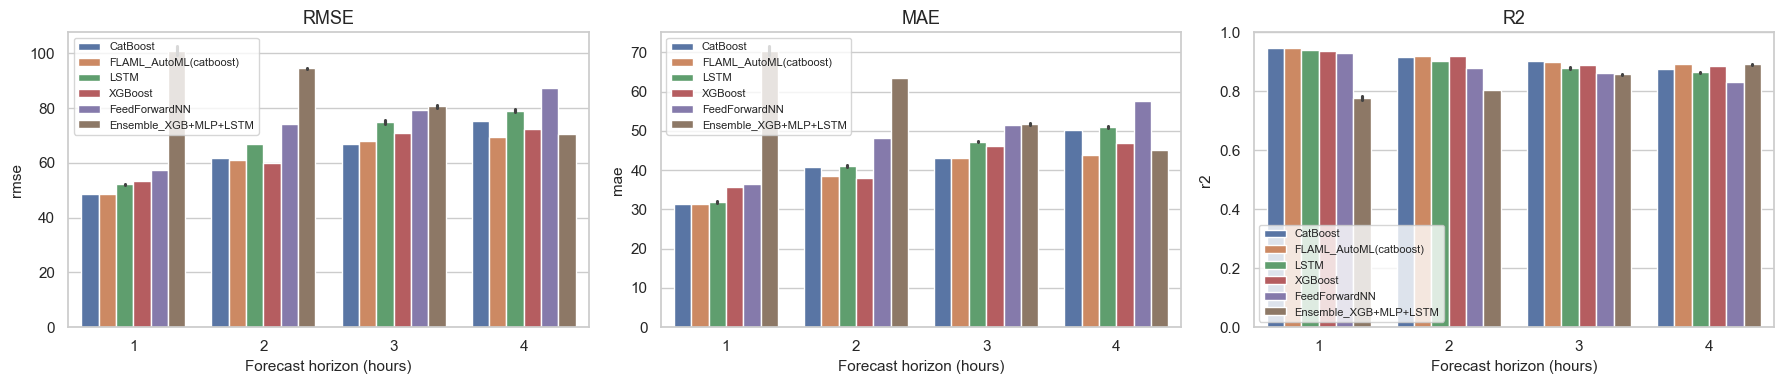

In [47]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
metrics_to_plot = ['rmse', 'mae', 'r2']

for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(data=results_df, x='horizon', y=metric, hue='model', ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel('Forecast horizon (hours)')
    ax.tick_params(axis='x', rotation=0)
    if metric == 'r2':
        ax.set_ylim(0, 1)
    ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()



## 11. Key Takeaways

- Rich exploratory analysis (heat maps, seasonal decomposition, rolling stats) clarifies demand dynamics before modelling.
- Stationarity tests and STL decomposition guide classical ARIMA/SARIMAX modelling choices.
- Tree ensembles profit from carefully engineered lag/seasonal/EMA features and deliver strong multi-horizon accuracy.
- Neural networks (dense + LSTM) benefit from feature scaling and sequence construction; combining them with tree models yields robust ensembles.
- AutoML provides a competitive baseline, but custom ensembles remain advantageous when domain-specific features are available.

Feel free to extend the pipeline with probabilistic forecasting, gradient boosting libraries such as LightGBM, or hyperparameter optimisation via Bayesian methods.
